# Recession Probability - Dynamic Factor Markov Switching Model - FRED

In [1]:
import pandas as pd
import yfinance as yf

yf.pdr_override()
import os
from dotenv import load_dotenv
from fredapi import Fred
import matplotlib.pyplot as plt

%matplotlib inline

ModuleNotFoundError: No module named 'yfinance'

In [ ]:
fred = Fred(api_key="612c90fb30af12767bbcaf9513bac5ed")

#### Smoothed recession probabilities for the United States are obtained from a dynamic-factor markov-switching model applied to four monthly coincident variables: non-farm payroll employment, the index of industrial production, real personal income excluding transfer payments, and real manufacturing and trade sales.

#### The forecast has a delay of approx. 3 months due to delay between collecting data and computation of the forecast.

##### Source: [FRED](https://fred.stlouisfed.org/series/RECPROUSM156N), [The FRED Blog](https://fredblog.stlouisfed.org/2015/05/how-likely-is-a-recession-and-how-fast-is-a-forecast/?utm_source=series_page&utm_medium=related_content&utm_term=related_resources&utm_campaign=fredblog)

In [ ]:
# Pull recession probabilities
recession_prob = fred.get_series("RECPROUSM156N", observation_start="1990-01-01")
recession_prob = recession_prob.dropna()
recession_prob.tail()

2023-09-01    0.06
2023-10-01    0.44
2023-11-01    0.04
2023-12-01    0.08
2024-01-01    0.26
dtype: float64

In [ ]:
# Pull S&P Index historical values from yfinance API
ticker = "^GSPC"
start = "1990-01-01"
end = "2023-03-02"

sp_history = yf.download(ticker, start=start, end=end, progress=False)
sp_history = sp_history.asfreq(freq="D").ffill().dropna()
sp_history.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-02-25,3973.239990,3978.250000,3943.080078,3970.040039,3970.040039,3.877700e+09
2023-02-26,3973.239990,3978.250000,3943.080078,3970.040039,3970.040039,3.877700e+09
2023-02-27,3992.360107,4018.050049,3973.550049,3982.239990,3982.239990,3.836950e+09
2023-02-28,3977.189941,3997.500000,3968.979980,3970.149902,3970.149902,5.043400e+09
2023-03-01,3963.340088,3971.729980,3939.050049,3951.389893,3951.389893,4.249480e+09


In [ ]:
# Pull VIX historical data
ticker = "^VIX"
start = "1990-01-01"
end = "2022-04-02"

vix_history = yf.download(ticker, start=start, end=end, progress=False)
vix_history = vix_history.asfreq(freq="D").ffill().dropna()
vix_history.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-03-28,22.139999,23.330000,19.540001,19.629999,19.629999,0.0
2022-03-29,19.700001,19.730000,18.670000,18.900000,18.900000,0.0
2022-03-30,19.379999,20.510000,18.719999,19.330000,19.330000,0.0
2022-03-31,19.680000,21.480000,19.540001,20.559999,20.559999,0.0
2022-04-01,20.620001,20.860001,19.410000,19.629999,19.629999,0.0


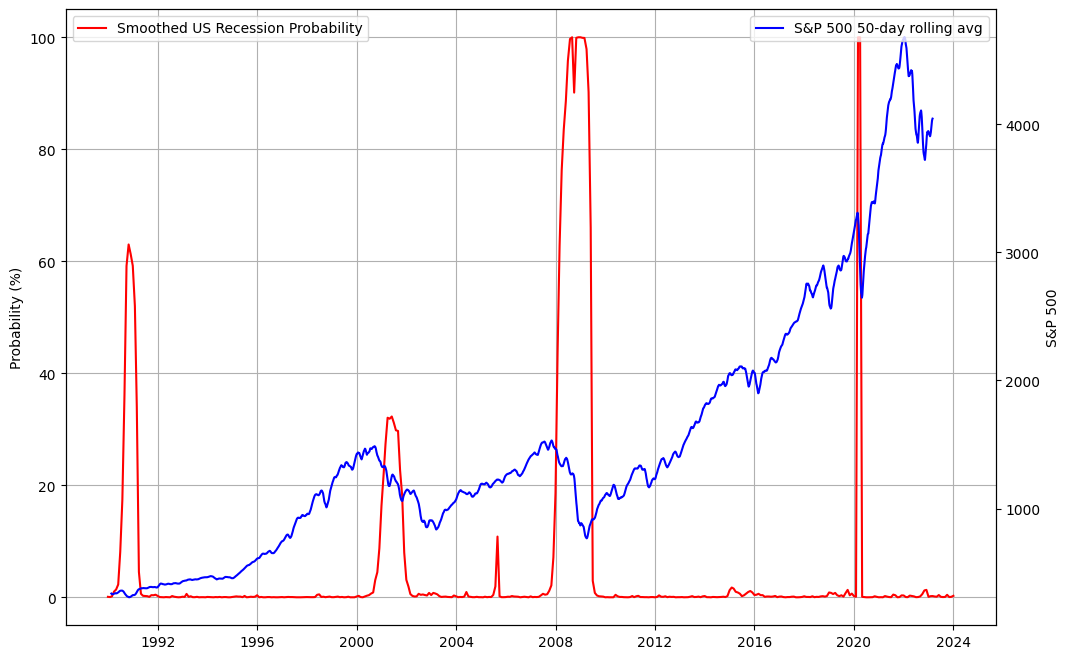

In [ ]:
# Plot Recession Probability vs S&P 500
fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(recession_prob, label="Smoothed US Recession Probability", color="r")
ax.set_ylabel("Probability (%)")
plt.grid()
ax.legend(loc="upper left")

ax2 = ax.twinx()
plt.plot(
    sp_history["Adj Close"].rolling(window=50).mean(),
    label="S&P 500 50-day rolling avg",
    color="b",
)
ax2.set_ylabel("S&P 500")
ax2.legend(loc="upper right")

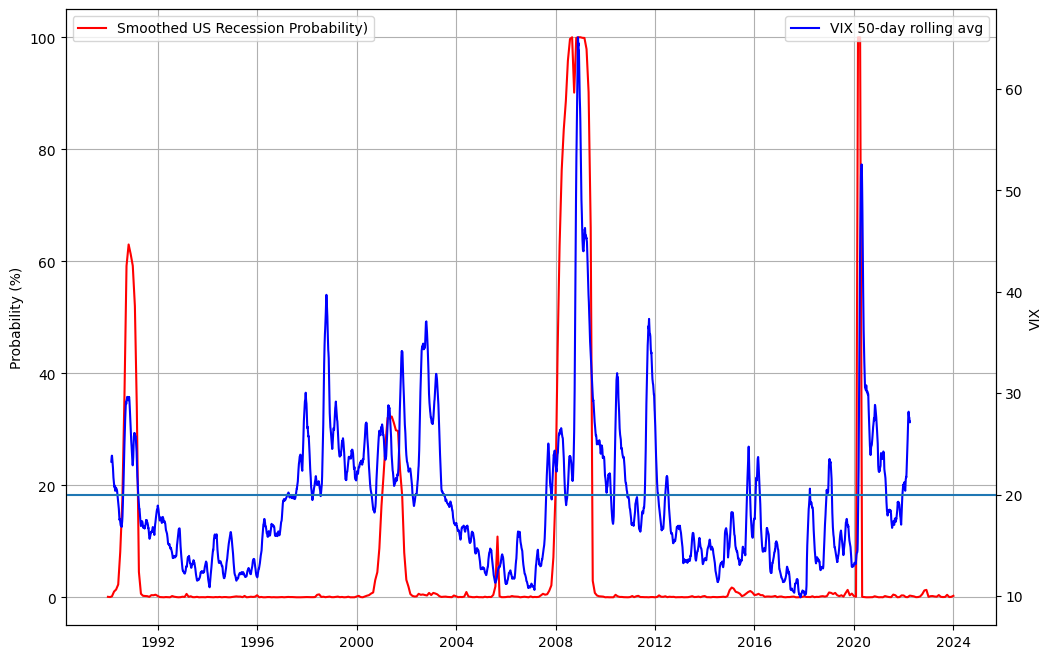

In [ ]:
# Plot Recession Probability vs VIX - value of 20 (arbitrarily selected) which is seen as fearful market
fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(recession_prob, label="Smoothed US Recession Probability)", color="r")
ax.set_ylabel("Probability (%)")
plt.grid()
ax.legend(loc="upper left")

ax2 = ax.twinx()
plt.plot(
    vix_history["Adj Close"].rolling(window=50).mean(),
    label="VIX 50-day rolling avg",
    color="b",
)
ax2.set_ylabel("VIX")
ax2.legend(loc="upper right")
ax2.axhline(y=20)

# Recession Probability - 10 Year-3 Month Treasury Spread

#### The 10 Year-3 Month Treasury Yield Spread is the difference between the 10 year treasury rate and the 3 month treasury rate. This spread is widely used as a gauge to study the yield curve. A 10 year-3 month treasury spread that approaches 0 signifies a "flattening" yield curve. Furthermore, a negative 10 year-3 month spread has historically been viewed as a precursor or predictor of a recessionary period. The New York Fed uses the rate in a model to predict recessions 2 to 6 quarters ahead.

##### Source: [YCharts](https://ycharts.com/indicators/10_year_3_month_treasury_spread), [Federal Reserve Bank of New York, The Yield Curve as a Leading Indicator](https://www.newyorkfed.org/research/capital_markets/ycfaq.html)


In [ ]:
# Pull 10-Year Treasury Constant Maturity Minus 3-Month Treasury Constant Maturity
ten_three_treasury_spread = fred.get_series("T10Y3M", observation_start="1990-01-01")
ten_three_treasury_spread = ten_three_treasury_spread.dropna()
ten_three_treasury_spread.tail()

2024-02-23   -1.20
2024-02-26   -1.19
2024-02-27   -1.14
2024-02-28   -1.18
2024-02-29   -1.20
dtype: float64

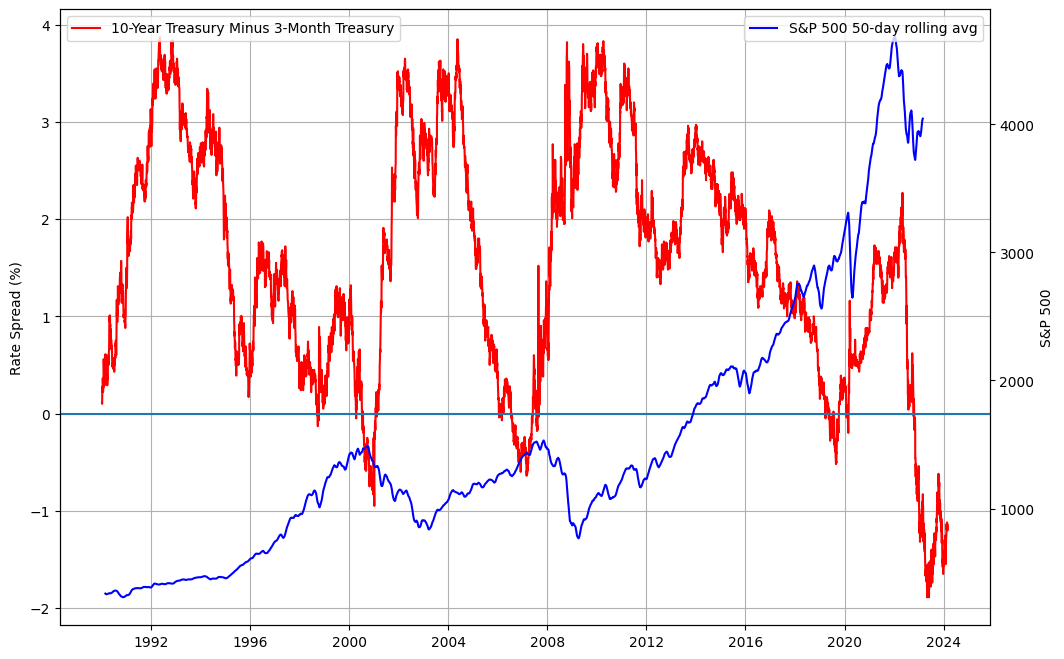

In [ ]:
# Plot Ten Year-3 Month Treasury spread vs S&P 500
fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(
    ten_three_treasury_spread,
    label="10-Year Treasury Minus 3-Month Treasury",
    color="r",
)
ax.set_ylabel("Rate Spread (%)")
plt.grid()
ax.legend(loc="upper left")
ax.axhline(y=0)

ax2 = ax.twinx()
plt.plot(
    sp_history["Adj Close"].rolling(window=50).mean(),
    label="S&P 500 50-day rolling avg",
    color="b",
)
ax2.set_ylabel("S&P 500")
ax2.legend(loc="upper right")

#### You may download calculated [recession probabilities](https://www.newyorkfed.org/research/capital_markets/ycfaq#/) in excel format from the Federal Reserve Bank of New York 

In [ ]:
treasury_spread_recession_prob = pd.read_csv(
    "data/allmonth.csv",
    usecols=["Rec_prob", "Date"],
)
treasury_spread_recession_prob = treasury_spread_recession_prob.dropna()
treasury_spread_recession_prob

,Date,Rec_prob
12,31-Jan-60,10.47%
13,28-Feb-60,9.76%
14,31-Mar-60,10.58%
15,30-Apr-60,10.86%
16,31-May-60,7.70%
...,...,...
788,9/30/24,56.16%
789,10/31/24,46.11%
790,11/30/24,51.84%
791,12/31/24,62.94%


In [ ]:
from dateutil.parser import parse

treasury_spread_recession_prob["Date"] = treasury_spread_recession_prob["Date"].apply(
    lambda x: x if "-" not in x else x[:-2] + "19" + x[-2:]
)
treasury_spread_recession_prob["Date"] = treasury_spread_recession_prob["Date"].apply(
    lambda x: x if "/" not in x else x[:-2] + "20" + x[-2:]
)
treasury_spread_recession_prob["Date"] = treasury_spread_recession_prob["Date"].apply(
    lambda x: parse(x).strftime("%Y-%m-%d")
)
treasury_spread_recession_prob = treasury_spread_recession_prob.set_index("Date")
treasury_spread_recession_prob

,Rec_prob
Date,
1960-01-31,10.47%
1960-02-28,9.76%
1960-03-31,10.58%
1960-04-30,10.86%
1960-05-31,7.70%
...,...
2024-09-30,56.16%
2024-10-31,46.11%
2024-11-30,51.84%


1990-01-02    0.11
1990-01-03    0.10
1990-01-04    0.14
1990-01-05    0.20
1990-01-08    0.23
              ... 
2024-02-23   -1.20
2024-02-26   -1.19
2024-02-27   -1.14
2024-02-28   -1.18
2024-02-29   -1.20
Length: 8547, dtype: float64
<class 'pandas.core.series.Series'>


TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x28f0ec970>.

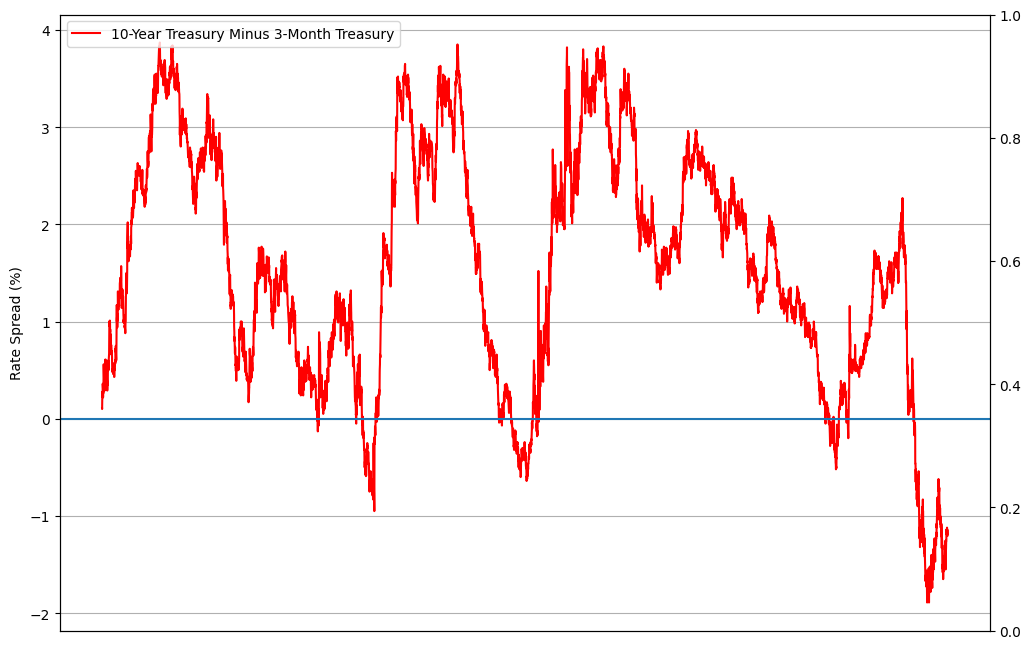

In [ ]:
# Plot Ten Year-3 Month Treasury spread vs Recession Probability till 03/31/23
print(ten_three_treasury_spread)
print(type(ten_three_treasury_spread))
ten_three_treasury_spread = pd.DataFrame(ten_three_treasury_spread).reset_index()
ten_three_treasury_spread.columns = ["Date", "data"]
# ten_three_treasury_spread = ten_three_treasury_spread.set_index("Date")

# ten_three_treasury_spread["Date"] = ten_three_treasury_spread["Date"].apply(
#     lambda x: parse(x).strftime("%Y-%m-%d")
# )
ten_three_treasury_spread = ten_three_treasury_spread.set_index("Date")

fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(
    ten_three_treasury_spread,
    label="10-Year Treasury Minus 3-Month Treasury",
    color="r",
)
ax.set_ylabel("Rate Spread (%)")
plt.grid()
ax.legend(loc="upper left")
ax.axhline(y=0)


ax2 = ax.twinx()
plt.plot(
    treasury_spread_recession_prob,
    label="Recession Probability",
    color="b",
)
ax2.set_ylabel("Rec Prob (%)")
ax2.legend(loc="upper right")

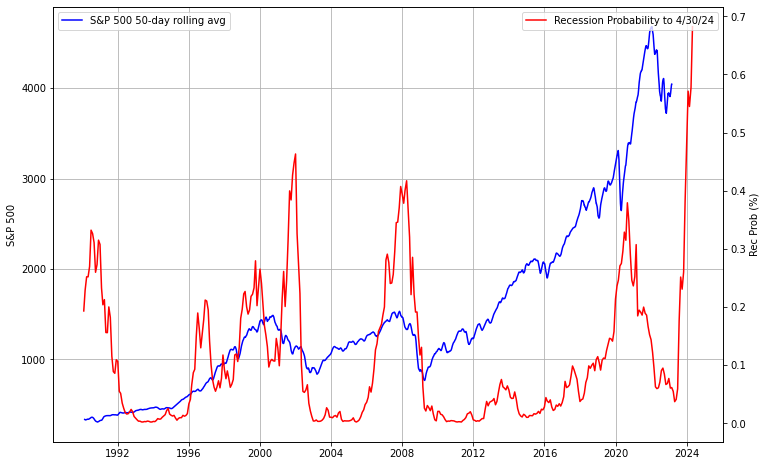

In [ ]:
# Plot Recession Probability vs S&P 500
fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(
    sp_history["Adj Close"].rolling(window=50).mean(),
    label="S&P 500 50-day rolling avg",
    color="b",
)
ax.set_ylabel("S&P 500")
plt.grid()
ax.legend(loc="upper left")

ax2 = ax.twinx()
plt.plot(
    treasury_spread_recession_prob["1990":],
    label="Recession Probability to 4/30/24",
    color="r",
)
ax2.set_ylabel("Rec Prob (%)")
ax2.legend(loc="upper right")

# NBER Recessions 
#### NBER based Recession Indicators for the United States from the Period following the Peak through the Trough

In [ ]:
# NBER based Recession Indicators for the United States from the Period following the Peak through the Trough
nber_monthly = fred.get_series("USREC", observation_start="1854-12-01")
nber_monthly = pd.DataFrame(nber_monthly, columns={"USREC"})
nber_monthly

,USREC
1854-12-01,1.0
1855-01-01,0.0
1855-02-01,0.0
1855-03-01,0.0
1855-04-01,0.0
...,...
2022-12-01,0.0
2023-01-01,0.0
2023-02-01,0.0
2023-03-01,0.0


<AxesSubplot:title={'center':'US Recessions 1945-2023 (value 1 represents recession)'}>

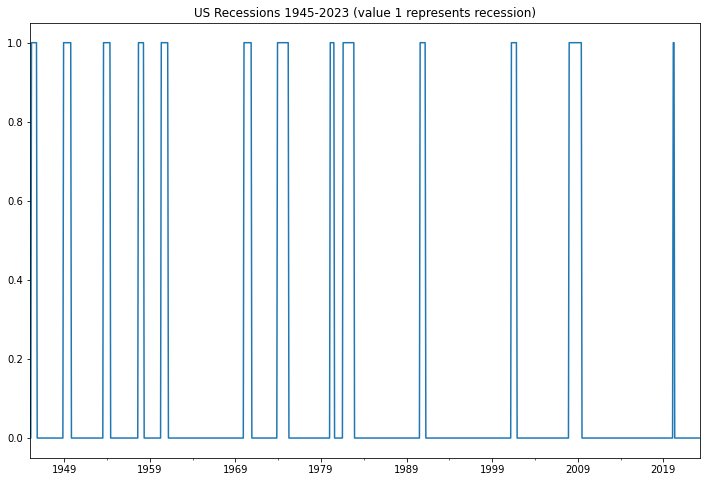

In [ ]:
# Plot US recessions from 1945 onwards
nber_monthly = nber_monthly["USREC"]["1945":]
nber_monthly.plot(
    figsize=(12, 8), title="US Recessions 1945-2023 (value 1 represents recession)"
)

In [ ]:
# Number of recessions from 1945 onwards
count_recession = nber_monthly.diff().eq(1).sum()
count_recession

13

In [ ]:
# Number of recession months
recession_months = nber_monthly.shift().eq(1).sum()
recession_months

132

In [ ]:
# Number of expansion months
expansion_months = nber_monthly.shift().ne(1).sum()
expansion_months

808

In [ ]:
# Average recession length
average_recession = recession_months / count_recession
average_recession

10.153846153846153

In [ ]:
# Calculate total number of groups - recessions and expansions
nber_monthly = pd.DataFrame(nber_monthly)
nber_monthly["USREC_x"] = nber_monthly.shift()
nber_monthly["cumsum"] = (nber_monthly["USREC"] != nber_monthly["USREC_x"]).cumsum()
nber_monthly

,USREC,USREC_x,cumsum
1945-01-01,0.0,NaN,1
1945-02-01,0.0,0.0,1
1945-03-01,1.0,0.0,2
1945-04-01,1.0,1.0,2
1945-05-01,1.0,1.0,2
...,...,...,...
2022-12-01,0.0,0.0,27
2023-01-01,0.0,0.0,27
2023-02-01,0.0,0.0,27
2023-03-01,0.0,0.0,27


In [ ]:
# Average expansion length
average_expansion = expansion_months / (nber_monthly["cumsum"][-1] - count_recession)
average_expansion

57.714285714285715